In [1]:
# --! include root folders into PYTHONPATH --!

import os
import sys

dir_this = os.getcwd()
dir_example = os.path.abspath(os.path.join(dir_this, '..'))
sys.path.append(dir_example)
dir_root = os.path.abspath(os.path.join(dir_this, '..', '..', '..'))
sys.path.append(dir_root)

import torch
import numpy as np
from matplotlib import pyplot as plt

import example_mujoco
import util_data
import util_nn
import kind

data_path = '../../../data/mujoco'
model_path = '../../../models/mujoco'
result_path = '../../../results/mujoco'

In [2]:
# --! specify kind arguments

parser = kind.create_args_parser()
args = parser.parse_args(
    args=[
        '--file_dir', data_path,
        '--file_name', 'walker2d',
        '--data_nsample_baseline', '918',
        '--data_nsample_nom', '48',
        '--data_nsample_exc', '48',
        '--obs_ndim', '17',
        '--act_ndim', '6',
        '--target_ndim', '17',
        '--data_train_size', '0.8',

        '--back_nsample', '32',
        '--fore_nsample', '16',

        '--batch_size', '128',
        '--learning_rate', '0.001',
        '--weight_decay', '0.000001',
        '--nepoch', '1000',
        '--patience', '100',
        '--checkpoints', f'{model_path}/walker2d',

        '--rez_nsample_nom', '16',
        '--rez_nsample_exc', '8',
        '--embed_nom', '{"sin": 10, "cos": 10}',
        '--embed_exc', '{"data": 20}',
    ]
)

setpoint = torch.zeros(args.target_ndim)

In [3]:
# --! create model, dataset and training

model = kind.model(args)
dataset = example_mujoco.dataset(args, setpoint, load_normalized=True, extract_windows=False)
training = kind.training(model)

In [4]:
model.train()
training.fit(dataset)

>>> training nominal mean >>>
	epoch 1 losses: train=0.410195, valid=0.164368, test=0.166552
	validation loss decreased (inf -> 0.164368), saving model ...
	epoch 2 losses: train=0.127414, valid=0.100182, test=0.101159
	validation loss decreased (0.164368 -> 0.100182), saving model ...
	epoch 3 losses: train=0.087371, valid=0.078359, test=0.079166
	validation loss decreased (0.100182 -> 0.078359), saving model ...
	epoch 4 losses: train=0.070639, valid=0.065321, test=0.065810
	validation loss decreased (0.078359 -> 0.065321), saving model ...
	epoch 5 losses: train=0.061200, valid=0.058473, test=0.058891
	validation loss decreased (0.065321 -> 0.058473), saving model ...
	epoch 6 losses: train=0.055659, valid=0.053721, test=0.054068
	validation loss decreased (0.058473 -> 0.053721), saving model ...
	epoch 7 losses: train=0.051558, valid=0.050056, test=0.050385
	validation loss decreased (0.053721 -> 0.050056), saving model ...
	epoch 8 losses: train=0.048389, valid=0.046805, test=0.04

In [5]:
model.eval()
data_loader, _, _ = dataset.load(data_type='nom')

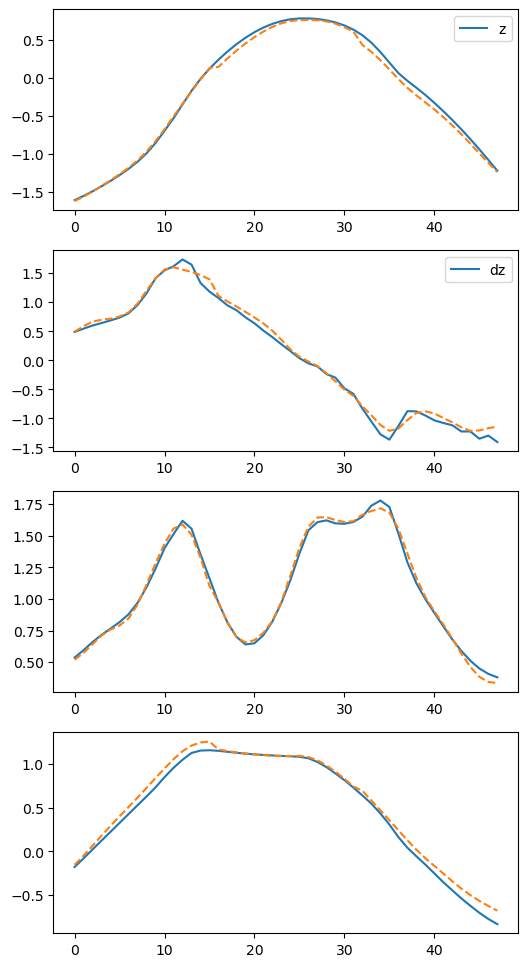

In [10]:
jdata = 4

with torch.no_grad():
    for back, fore in data_loader:
        true = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_nom = model_o.mean_nom

        plt.figure(figsize=(6,12))

        plt.subplot(4,1,1)
        plt.plot(true[jdata, :, 0], label='z')
        plt.plot(mean_nom[0, :, 0], linestyle='dashed')
        plt.legend()

        plt.subplot(4,1,2)
        plt.plot(true[jdata, :, 9], label='dz')
        plt.plot(mean_nom[0, :, 9], linestyle='dashed')
        plt.legend()

        plt.subplot(4,1,3)
        plt.plot(true[jdata, :, 1])
        plt.plot(mean_nom[0, :, 1], linestyle='dashed')

        plt.subplot(4,1,4)
        plt.plot(true[jdata, :, 2])
        plt.plot(mean_nom[0, :, 2], linestyle='dashed')

        plt.show()

        break

### Training nominal uncertainty

In [11]:
# --! switch to next training phase - nominal uncertainty - and train
model.train()
training.fit_next()
training.fit(dataset)

>>> training nominal uncertainty >>>
	epoch 1 losses: train=0.064990, valid=0.058510, test=0.060380
	validation loss decreased (inf -> 0.058510), saving model ...
	epoch 2 losses: train=0.055059, valid=0.050087, test=0.052199
	validation loss decreased (0.058510 -> 0.050087), saving model ...
	epoch 3 losses: train=0.048489, valid=0.047131, test=0.048941
	validation loss decreased (0.050087 -> 0.047131), saving model ...
	epoch 4 losses: train=0.045734, valid=0.043950, test=0.045053
	validation loss decreased (0.047131 -> 0.043950), saving model ...
	epoch 5 losses: train=0.041655, valid=0.040194, test=0.040945
	validation loss decreased (0.043950 -> 0.040194), saving model ...
	epoch 6 losses: train=0.038551, valid=0.037697, test=0.038403
	validation loss decreased (0.040194 -> 0.037697), saving model ...
	epoch 7 losses: train=0.036554, valid=0.035916, test=0.036440
	validation loss decreased (0.037697 -> 0.035916), saving model ...
	epoch 8 losses: train=0.035515, valid=0.034812, te

In [12]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

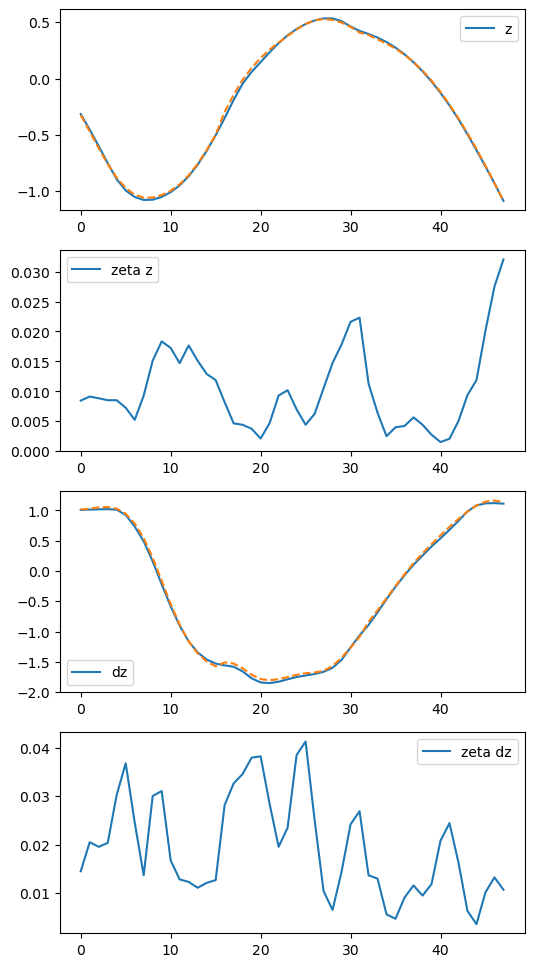

In [23]:
jdata = 10

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_nom = model_o.mean_nom
        zeta_nom = model_o.zeta_nom

        plt.figure(figsize=(6,12))

        plt.subplot(4,1,1)
        plt.plot(truth[jdata, :, :1], label='z')
        plt.plot(mean_nom[0, :, :1], linestyle='dashed')
        plt.legend()

        plt.subplot(4,1,2)
        plt.plot(zeta_nom[0, :, :1], label='zeta z')
        plt.legend()

        plt.subplot(4,1,3)
        plt.plot(truth[jdata, :, 6], label='dz')
        plt.plot(mean_nom[0, :, 6], linestyle='dashed')
        plt.legend()

        plt.subplot(4,1,4)
        plt.plot(zeta_nom[0, :, 6], label='zeta dz')
        plt.legend()

        plt.show()

        break

### Training excursion model

In [24]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion mean >>>
	epoch 1 losses: train=0.540760, valid=0.258417, test=0.262230
	validation loss decreased (inf -> 0.258417), saving model ...
	epoch 2 losses: train=0.192519, valid=0.148980, test=0.151132
	validation loss decreased (0.258417 -> 0.148980), saving model ...
	epoch 3 losses: train=0.128909, valid=0.104961, test=0.105959
	validation loss decreased (0.148980 -> 0.104961), saving model ...
	epoch 4 losses: train=0.093277, valid=0.081085, test=0.081903
	validation loss decreased (0.104961 -> 0.081085), saving model ...
	epoch 5 losses: train=0.075959, valid=0.072994, test=0.073911
	validation loss decreased (0.081085 -> 0.072994), saving model ...
	epoch 6 losses: train=0.066741, valid=0.062477, test=0.062978
	validation loss decreased (0.072994 -> 0.062477), saving model ...
	epoch 7 losses: train=0.059766, valid=0.058165, test=0.058540
	validation loss decreased (0.062477 -> 0.058165), saving model ...
	epoch 8 losses: train=0.055286, valid=0.054098, test=0.

In [25]:
model.eval()
_, _, data_loader = dataset.load(data_type='exc')

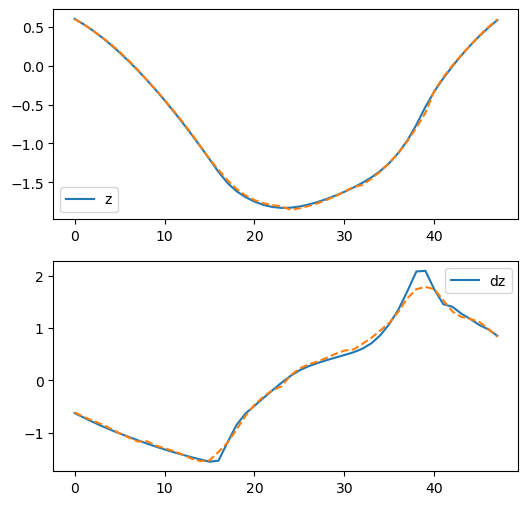

In [34]:
jdata = 8

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_exc = model_o.mean_exc

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :1], label='z')
        plt.plot(mean_exc[0, :, :1], linestyle='dashed')
        plt.legend()

        plt.subplot(2,1,2)
        plt.plot(truth[jdata, :, 9], label='dz')
        plt.plot(mean_exc[0, :, 9], linestyle='dashed')
        plt.legend()

        plt.show()

        break

### Training excursion uncertainty

In [35]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion uncertainty >>>
	epoch 1 losses: train=0.213117, valid=0.146593, test=0.143192
	validation loss decreased (inf -> 0.146593), saving model ...
	epoch 2 losses: train=0.127123, valid=0.111700, test=0.108850
	validation loss decreased (0.146593 -> 0.111700), saving model ...
	epoch 3 losses: train=0.099927, valid=0.092374, test=0.090077
	validation loss decreased (0.111700 -> 0.092374), saving model ...
	epoch 4 losses: train=0.087773, valid=0.084610, test=0.082314
	validation loss decreased (0.092374 -> 0.084610), saving model ...
	epoch 5 losses: train=0.081212, valid=0.079931, test=0.077867
	validation loss decreased (0.084610 -> 0.079931), saving model ...
	epoch 6 losses: train=0.075364, valid=0.072711, test=0.070577
	validation loss decreased (0.079931 -> 0.072711), saving model ...
	epoch 7 losses: train=0.070630, valid=0.068521, test=0.066431
	validation loss decreased (0.072711 -> 0.068521), saving model ...
	epoch 8 losses: train=0.067055, valid=0.066059, 

In [36]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

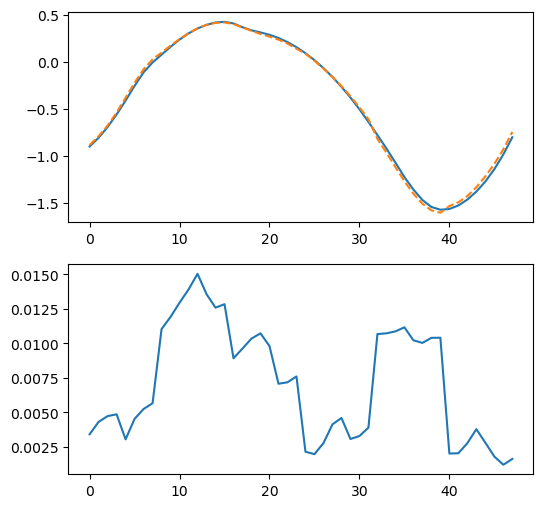

In [48]:
jdata = 11

with torch.no_grad():
    for back, fore in data_loader:
        true = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_exc = model_o.mean_exc
        zeta_exc = model_o.zeta_exc

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(true[jdata, :, :1])
        plt.plot(mean_exc[0, :, :1], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(zeta_exc[0, :, :1])

        plt.show()

        break

### Evaluating KIND blending

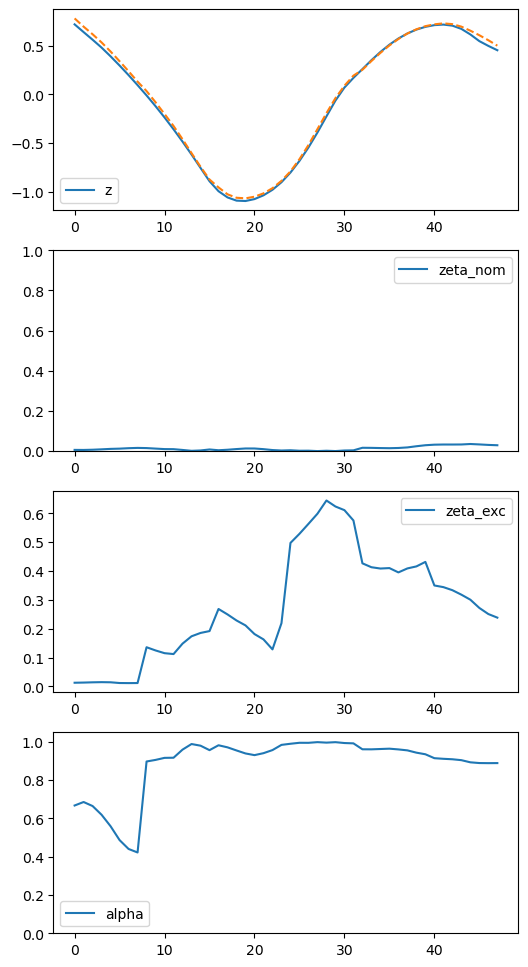

In [51]:
jdata = 2

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        pred = model_o.blend
        zeta_nom = model_o.zeta_nom
        zeta_exc = model_o.zeta_exc
        alpha = model_o.alpha

        plt.figure(figsize=(6,12))

        plt.subplot(4,1,1)
        plt.plot(truth[jdata, :, :1], label='z')
        plt.plot(pred[0, :, :1], linestyle='dashed')
        plt.legend()

        plt.subplot(4,1,2)
        plt.plot(zeta_nom[0, :, :1], label='zeta_nom')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,3)
        plt.plot(zeta_exc[0, :, :1], label='zeta_exc')
        plt.legend()

        plt.subplot(4,1,4)
        plt.plot(alpha[0, :, :1], label='alpha')
        plt.ylim((0.0, 1.05))
        plt.legend()

        plt.show()

        break